I am revisiting the machine learning assignment from my machine learning class, except I am using Python to complete the same assignment.

The goal of this project is to accurately identify the "Dx.Cancer" variable (a positive diagnosis of cervical cancer) from the Cervical Cancer Risk Factors dataset available from the UCI Machine Learning Repository.

In [119]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support,
    roc_auc_score, accuracy_score, PrecisionRecallDisplay, RocCurveDisplay,
    recall_score, make_scorer, precision_score, f1_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone
from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import joblib

In [77]:
# Load the dataset
cc_risk = pd.read_csv("/run/media/bruce/WD/PhD/LEARN/Assignment 1/risk_factors_cervical_cancer.csv", na_values="?")

In [78]:
# Initial data inspection
print(cc_risk.info())

# Count NAs
print(cc_risk.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

Both "STDs:Time since" columns have excessive missingness. They will be dropped as there is too little data available to adequately impute the missing data. There can be a wide range of values that may not be adequately captured during imputation.

Column names need to be cleaned up to avoid errors during analysis and modeling.

"Biopsy", "Hinselmann", "Citology", and "Schiller" are all diagnostic tests that confirm a positive cervical cancer diagnosis. These are leakage variables and will be removed to prevent introducing leakage into the model.

In [79]:
# Clean column names
cc_risk.columns = [re.sub(r'[^a-zA-Z0-9]', '', col) for col in cc_risk.columns]
cc_risk

,Age,Numberofsexualpartners,Firstsexualintercourse,Numofpregnancies,Smokes,Smokesyears,Smokespacksyear,HormonalContraceptives,HormonalContraceptivesyears,IUD,...,STDsTimesincefirstdiagnosis,STDsTimesincelastdiagnosis,DxCancer,DxCIN,DxHPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.00,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,...,NaN,NaN,0,0,0,0,0,0,1,0
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [80]:
# Remove leakage variables
leakage_vars = ["Biopsy", "Hinselmann", "Citology", "Schiller"]
cc_risk = cc_risk.drop(columns=leakage_vars, errors='ignore')
cc_risk

,Age,Numberofsexualpartners,Firstsexualintercourse,Numofpregnancies,Smokes,Smokesyears,Smokespacksyear,HormonalContraceptives,HormonalContraceptivesyears,IUD,...,STDsHIV,STDsHepatitisB,STDsHPV,STDsNumberofdiagnosis,STDsTimesincefirstdiagnosis,STDsTimesincelastdiagnosis,DxCancer,DxCIN,DxHPV,Dx
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.00,0.0,...,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.00,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.00,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0


In [81]:
# Remove columns with excessive missingness
cc_risk = cc_risk.drop(columns=['STDsTimesincefirstdiagnosis', 'STDsTimesincelastdiagnosis'], errors='ignore')
cc_risk

,Age,Numberofsexualpartners,Firstsexualintercourse,Numofpregnancies,Smokes,Smokesyears,Smokespacksyear,HormonalContraceptives,HormonalContraceptivesyears,IUD,...,STDsmolluscumcontagiosum,STDsAIDS,STDsHIV,STDsHepatitisB,STDsHPV,STDsNumberofdiagnosis,DxCancer,DxCIN,DxHPV,Dx
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,0,1,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0


In [82]:
# Convert Age and STDsNumberofdiagnosis to numeric
numeric_cols = ['Age', 'STDsNumberofdiagnosis']
cc_risk[numeric_cols] = cc_risk[numeric_cols].apply(pd.to_numeric, errors='coerce')
cc_risk

,Age,Numberofsexualpartners,Firstsexualintercourse,Numofpregnancies,Smokes,Smokesyears,Smokespacksyear,HormonalContraceptives,HormonalContraceptivesyears,IUD,...,STDsmolluscumcontagiosum,STDsAIDS,STDsHIV,STDsHepatitisB,STDsHPV,STDsNumberofdiagnosis,DxCancer,DxCIN,DxHPV,Dx
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,0,1,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0


Data has been cleaned and is ready for a train/test split to avoid leakage.

In [83]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=250, 
    stratify=y  # Important for imbalanced targets
)

Several of the variables have clinical overlap (e.g., they report the same type of measure, just in a different way - such as IUD and IUDyears). Will complete a near-zero variance analysis to determine variables that can be removed due to lack of statistical power.

In [84]:
# Near-zero variance analysis
variance_threshold = VarianceThreshold(threshold=0.01)
variance_threshold.fit(X_train)

# Identify low-variance columns
low_variance_mask = ~variance_threshold.get_support()
low_variance_cols = X_train.columns[low_variance_mask].tolist()

print(low_variance_cols)

['STDscervicalcondylomatosis', 'STDsvaginalcondylomatosis', 'STDspelvicinflammatorydisease', 'STDsgenitalherpes', 'STDsmolluscumcontagiosum', 'STDsAIDS', 'STDsHepatitisB', 'STDsHPV', 'DxCIN']


A brief literature review was conducted as well. Some of the near-zero variance variables are associated with cervical cancer in the literature. However, there is a lack of statistical power of these variables.

In [85]:
# Remove variables based on NZV analysis and domain knowledge
additional_remove = [
    'STDsAIDS', 'STDscervicalcondylomatosis', 'STDsHPV',
    'STDsmolluscumcontagiosum', 'STDsgenitalherpes',
    'STDsHepatitisB', 'STDsvaginalcondylomatosis',
    'STDspelvicinflammatorydisease'
]

X_train = X_train.drop(columns=additional_remove, errors='ignore')
X_test = X_test.drop(columns=additional_remove, errors='ignore')

X_train

,Age,Numberofsexualpartners,Firstsexualintercourse,Numofpregnancies,Smokes,Smokesyears,Smokespacksyear,HormonalContraceptives,HormonalContraceptivesyears,IUD,...,STDs,STDsnumber,STDscondylomatosis,STDsvulvoperinealcondylomatosis,STDssyphilis,STDsHIV,STDsNumberofdiagnosis,DxCIN,DxHPV,Dx
638,21,1.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
438,20,3.0,18.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
583,23,3.0,16.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
346,19,4.0,14.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
681,42,2.0,29.0,0.0,0.0,0.0,0.0,1.0,8.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,21,5.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
766,21,1.0,14.0,2.0,0.0,0.0,0.0,1.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
436,16,3.0,14.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
338,20,5.0,14.0,3.0,1.0,4.0,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


Will also complete a correlation analysis to determine the level of correlation between the remaining variables as there is still some overlap based on domain knowledge.

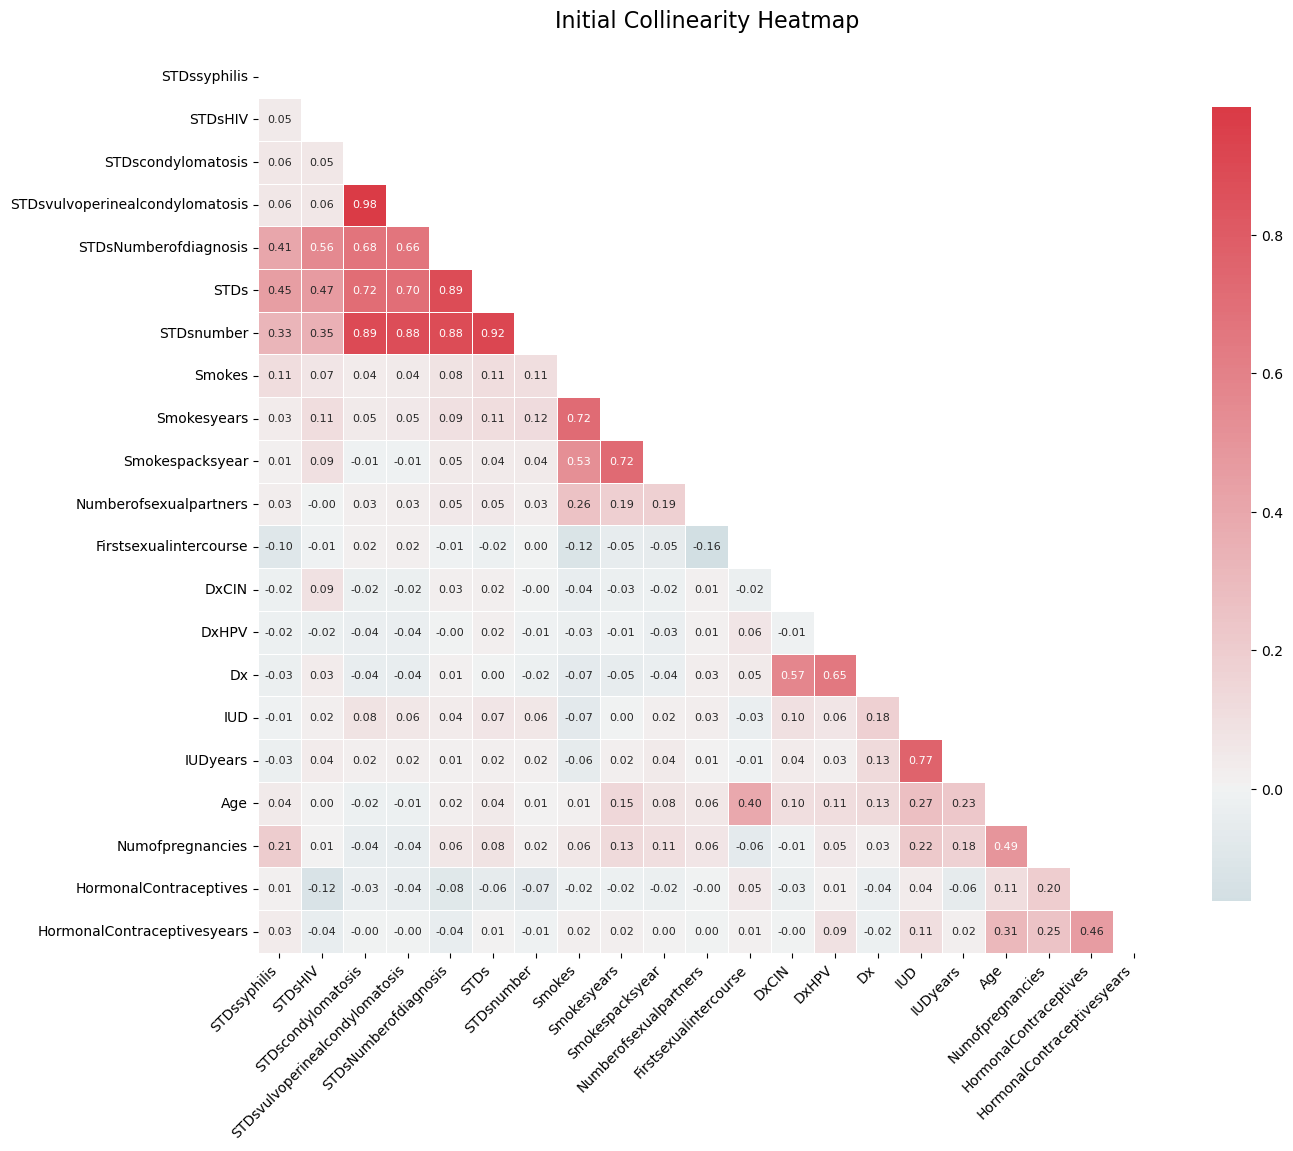


High Correlations (|r| >= 0.7) for Initial Collinearity Heatmap:
                               Var1                             Var2  \
0   STDsvulvoperinealcondylomatosis               STDscondylomatosis   
1                        STDsnumber                             STDs   
2                        STDsnumber               STDscondylomatosis   
3                              STDs            STDsNumberofdiagnosis   
4                        STDsnumber            STDsNumberofdiagnosis   
5                        STDsnumber  STDsvulvoperinealcondylomatosis   
6                          IUDyears                              IUD   
7                   Smokespacksyear                      Smokesyears   
8                       Smokesyears                           Smokes   
9                              STDs               STDscondylomatosis   
10                             STDs  STDsvulvoperinealcondylomatosis   

    Correlation  
0      0.984317  
1      0.916120  
2      0.892507

In [86]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

def plot_correlation_heatmap(data, title):
    """Create clustered correlation heatmap with annotations"""
    # Compute correlation matrix
    corr_matrix = data.corr()
    
    # Hierarchical clustering
    corr_condensed = squareform(1 - np.abs(corr_matrix))
    z = linkage(corr_condensed, method='ward')
    order = leaves_list(z)
    ordered_cols = corr_matrix.columns[order]
    corr_sorted = corr_matrix.iloc[order, order]
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_sorted, dtype=bool))
    
    # Setup figure
    plt.figure(figsize=(14, 12))
    plt.title(title, fontsize=16, pad=20)
    
    # Create custom color palette
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    
    # Create heatmap
    heatmap = sns.heatmap(
        corr_sorted,
        mask=mask,
        cmap=cmap,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8}
    )
    
    # Rotate labels
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Create high correlation table
    corr_triu = corr_sorted.mask(mask).stack().reset_index()
    corr_triu.columns = ['Var1', 'Var2', 'Correlation']
    high_corr = corr_triu[
        (abs(corr_triu['Correlation']) >= 0.7) & 
        (corr_triu['Var1'] != corr_triu['Var2'])
    ].sort_values(by='Correlation', ascending=False)
    
    # Remove duplicate pairs (A-B vs B-A)
    pairs_set = set()
    unique_high_corr = []
    
    for _, row in high_corr.iterrows():
        # Create sorted tuple of variable names
        pair = tuple(sorted([row['Var1'], row['Var2']]))
        # Check if we've seen this pair before
        if pair not in pairs_set:
            pairs_set.add(pair)
            unique_high_corr.append(row)
    
    # Convert back to DataFrame
    high_corr_unique = pd.DataFrame(unique_high_corr)
    
    print(f"\nHigh Correlations (|r| >= 0.7) for {title}:")
    print(high_corr_unique.reset_index(drop=True))
    
    return high_corr_unique

initial_high_corr = plot_correlation_heatmap(
    X_train, 
    "Initial Collinearity Heatmap"
)

There is extremely high correlation with 'STDscondylomatosis' and 'STDsvulvoperinealcondylomatosis'. Will remove both as there is no literature support for either.

There is also high correlation between 'DxHPV' and 'Dx' (0.65). 'DxHPV' is a diagnosis of herpes simplex virus (HSV). It is present in ~50-55% of positive cervical cancer diagnoses depending on literature source. It is likely a leakage variable given the clinical context. Will remove it due to clinical context and the high correlation with 'Dx'.

Will complete a more in-depth analysis of the 'STDs', 'STDsnumber', 'STDsNumberofdiagnosis', 'IUD', 'IUDyears', and the 'Smokes'-related features before dropping.

There are several similar features. It may be best to focus on years as a longer smoking history can increase the risk of cancer. 'Smokespacksyear' could also have more impact than 'Smokesyears' as heavier smoking (Smokespacksyear) increases the risk of cancer.

Need to keep in mind that DT and RF can handle multicollinearity, but it's still ideal to narrow down to more significant variables.

In [87]:
# Removed based on correlation
additional_corr_remove = ['STDscondylomatosis', 'STDsvulvoperinealcondylomatosis', 'DxHPV']
X_train = X_train.drop(columns=additional_corr_remove, errors='ignore')
X_test = X_test.drop(columns=additional_corr_remove, errors='ignore')
X_train

,Age,Numberofsexualpartners,Firstsexualintercourse,Numofpregnancies,Smokes,Smokesyears,Smokespacksyear,HormonalContraceptives,HormonalContraceptivesyears,IUD,IUDyears,STDs,STDsnumber,STDssyphilis,STDsHIV,STDsNumberofdiagnosis,DxCIN,Dx
638,21,1.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
438,20,3.0,18.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
583,23,3.0,16.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
346,19,4.0,14.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
681,42,2.0,29.0,0.0,0.0,0.0,0.0,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,21,5.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
766,21,1.0,14.0,2.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
436,16,3.0,14.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
338,20,5.0,14.0,3.0,1.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0


The remaining variables should be appropriate for modeling. However, there is still missing data for the remaining variables. A more in-depth missing data analysis will be completed to determine the best method(s) for imputation of missing data.


Missing Values Analysis:


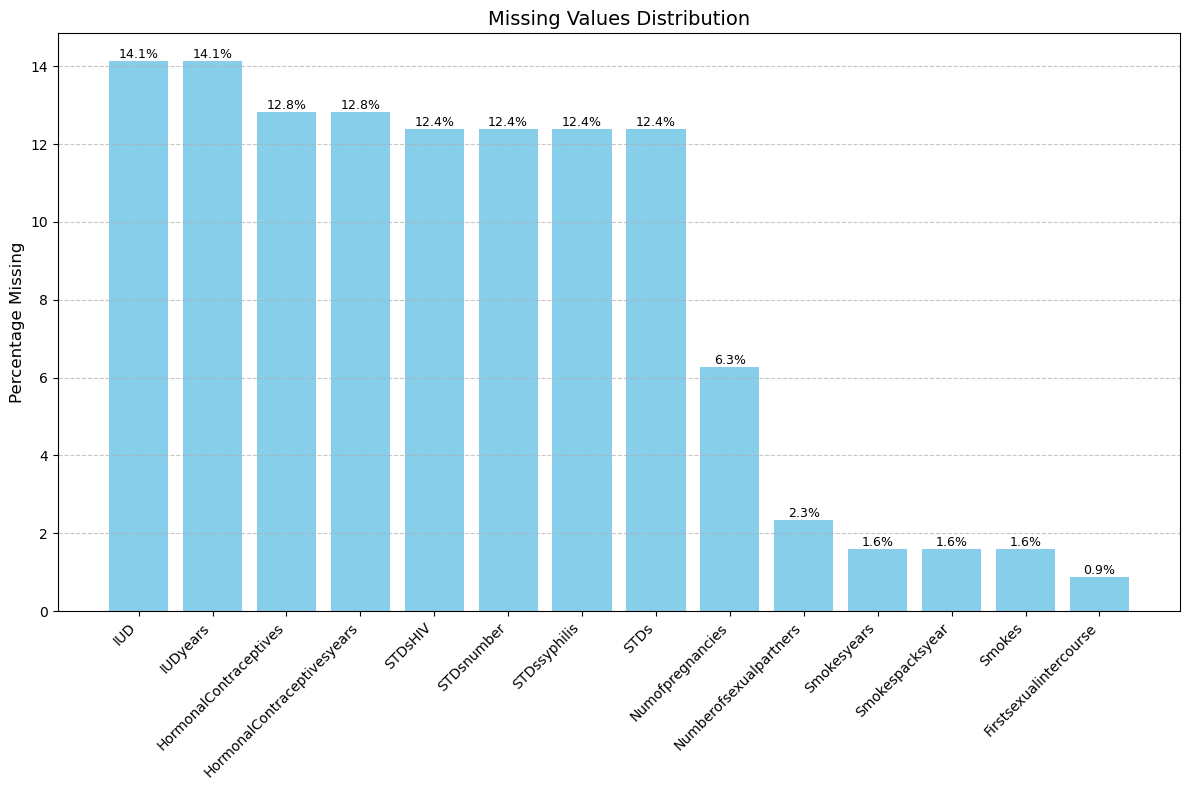


Analysis of 'HormonalContraceptives':
Missing values: 88/686 (12.8%)

Summary Statistics:
count    598.000000
mean       0.630435
std        0.483091
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000

Distribution Characteristics:
Mean: 0.63
Median: 1.00
Mode: 1.0


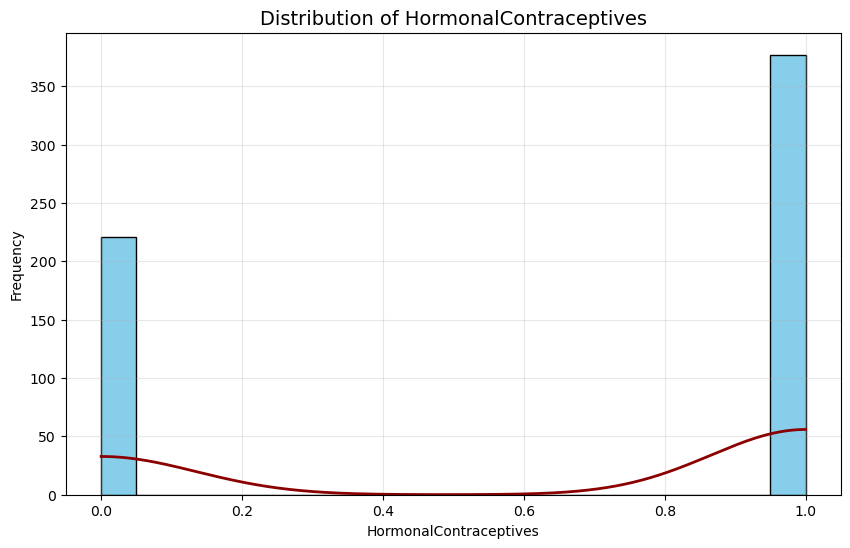


Analysis of 'HormonalContraceptivesyears':
Missing values: 88/686 (12.8%)

Summary Statistics:
count    598.000000
mean       2.238352
std        3.758319
min        0.000000
25%        0.000000
50%        0.420000
75%        3.000000
max       30.000000

Distribution Characteristics:
Mean: 2.24
Median: 0.42
Mode: 0.0


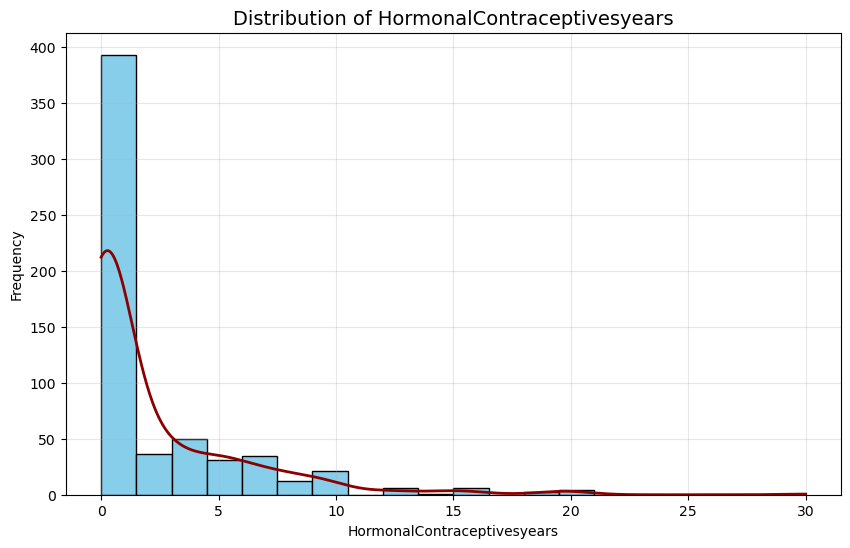


Analysis of 'STDs':
Missing values: 85/686 (12.4%)

Summary Statistics:
count    601.000000
mean       0.104825
std        0.306583
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000

Distribution Characteristics:
Mean: 0.10
Median: 0.00
Mode: 0.0


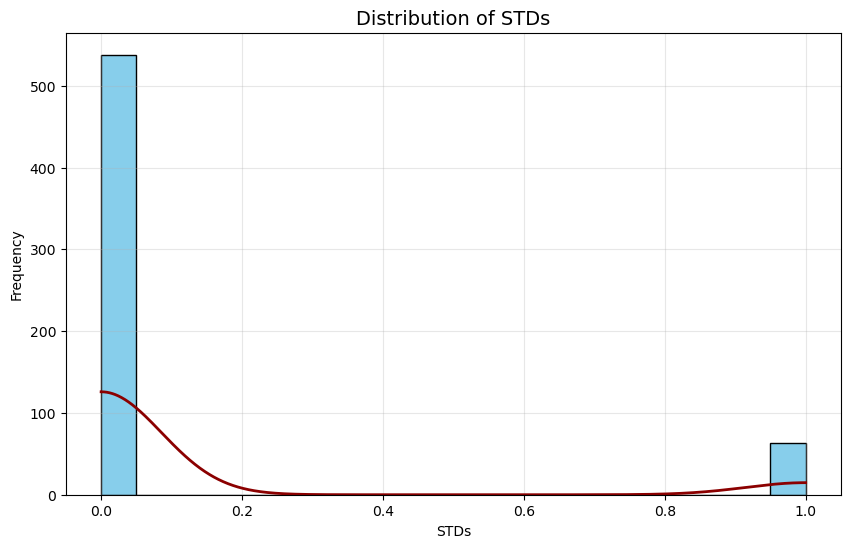


Analysis of 'STDsnumber':
Missing values: 85/686 (12.4%)

Summary Statistics:
count    601.000000
mean       0.174709
std        0.557757
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        4.000000

Distribution Characteristics:
Mean: 0.17
Median: 0.00
Mode: 0.0


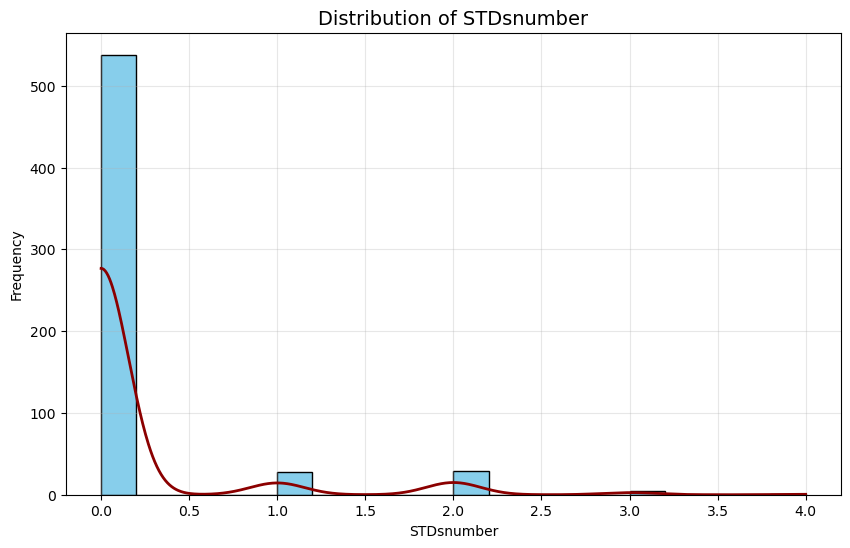


Analysis of 'STDsNumberofdiagnosis':
Missing values: 0/686 (0.0%)

Summary Statistics:
count    686.000000
mean       0.084548
std        0.298650
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        3.000000

Distribution Characteristics:
Mean: 0.08
Median: 0.00
Mode: 0


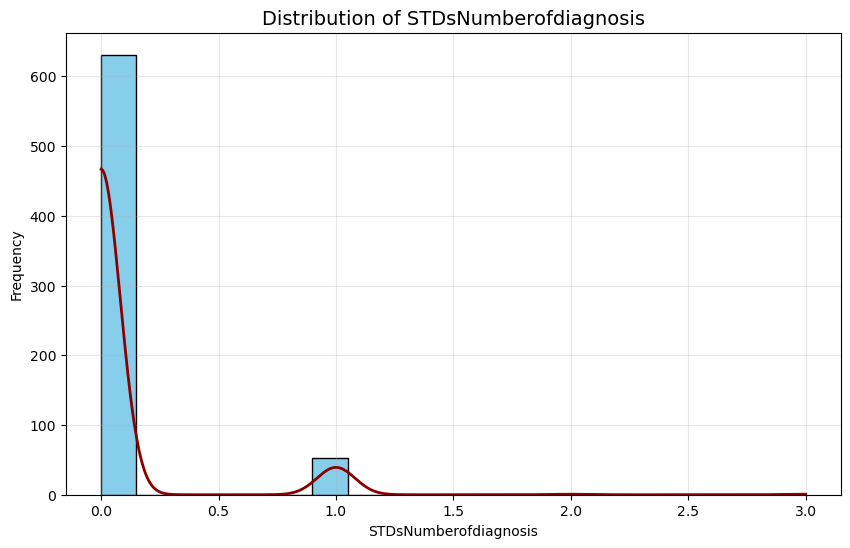


Analysis of 'Numofpregnancies':
Missing values: 43/686 (6.3%)

Summary Statistics:
count    643.000000
mean       2.256610
std        1.407954
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        8.000000

Distribution Characteristics:
Mean: 2.26
Median: 2.00
Mode: 1.0


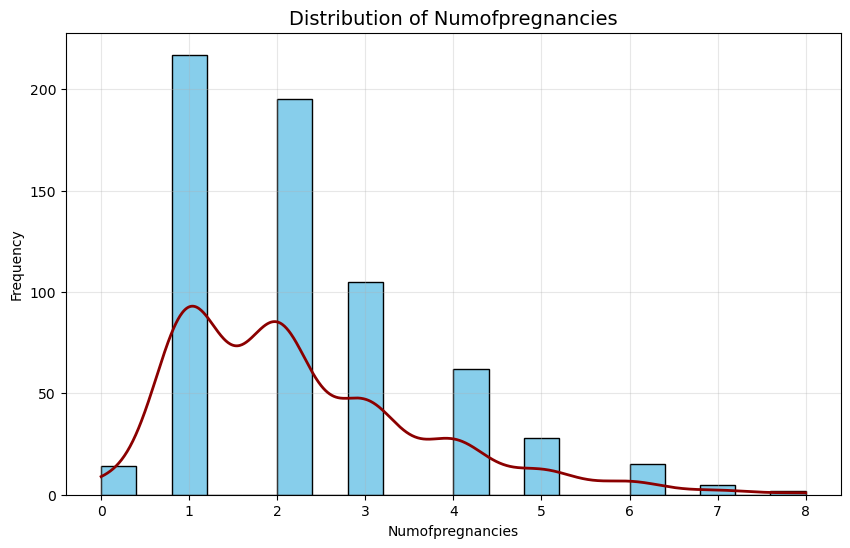


Analysis of 'Numberofsexualpartners':
Missing values: 16/686 (2.3%)

Summary Statistics:
count    670.000000
mean       2.588060
std        1.742936
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max       28.000000

Distribution Characteristics:
Mean: 2.59
Median: 2.00
Mode: 2.0


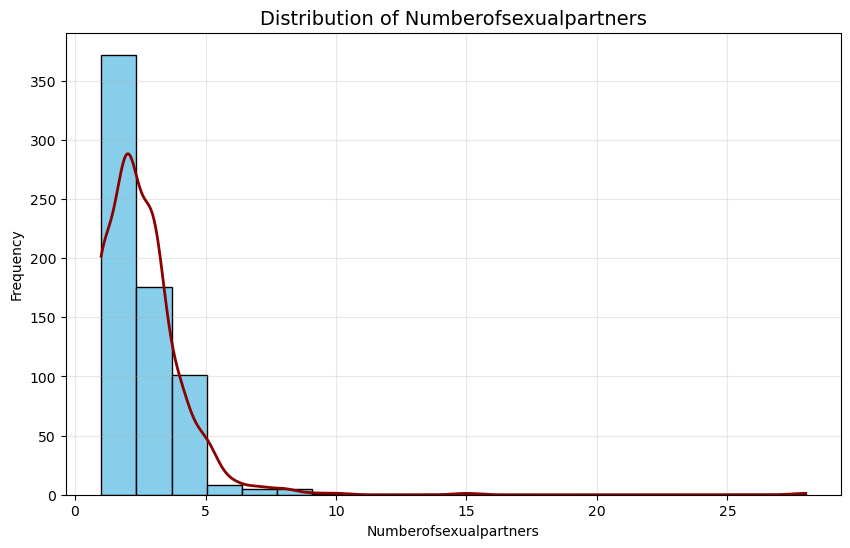


Analysis of 'Smokes':
Missing values: 11/686 (1.6%)

Summary Statistics:
count    675.000000
mean       0.139259
std        0.346474
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000

Distribution Characteristics:
Mean: 0.14
Median: 0.00
Mode: 0.0


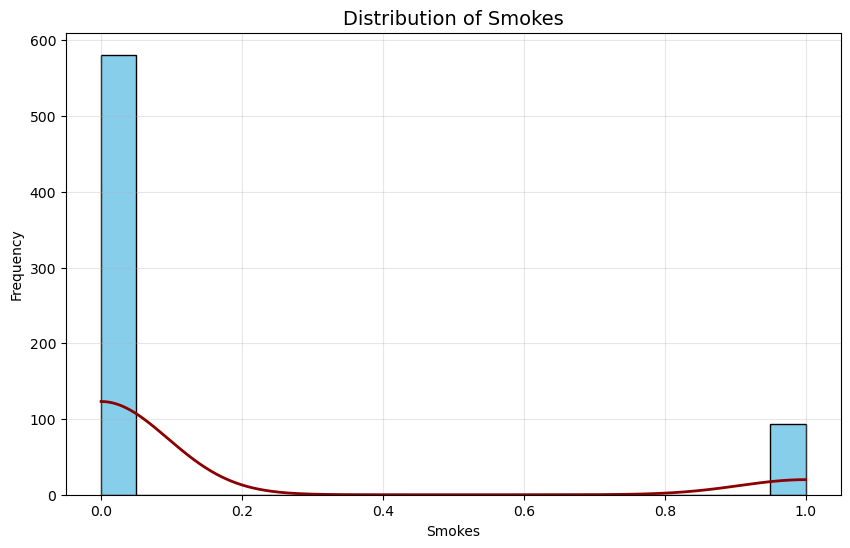


Analysis of 'Smokesyears':
Missing values: 11/686 (1.6%)

Summary Statistics:
count    675.000000
mean       1.066465
std        3.704062
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       34.000000

Distribution Characteristics:
Mean: 1.07
Median: 0.00
Mode: 0.0


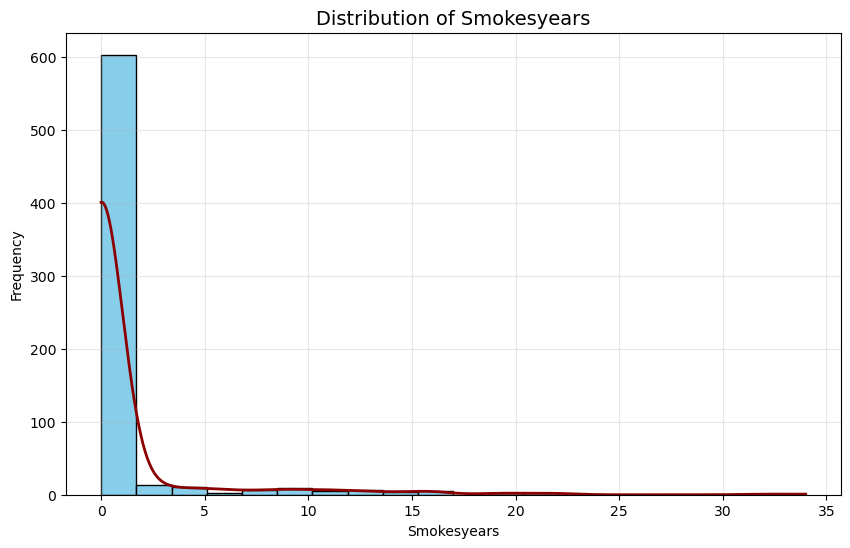


Analysis of 'Smokespacksyear':
Missing values: 11/686 (1.6%)

Summary Statistics:
count    675.000000
mean       0.388909
std        1.822927
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       22.000000

Distribution Characteristics:
Mean: 0.39
Median: 0.00
Mode: 0.0


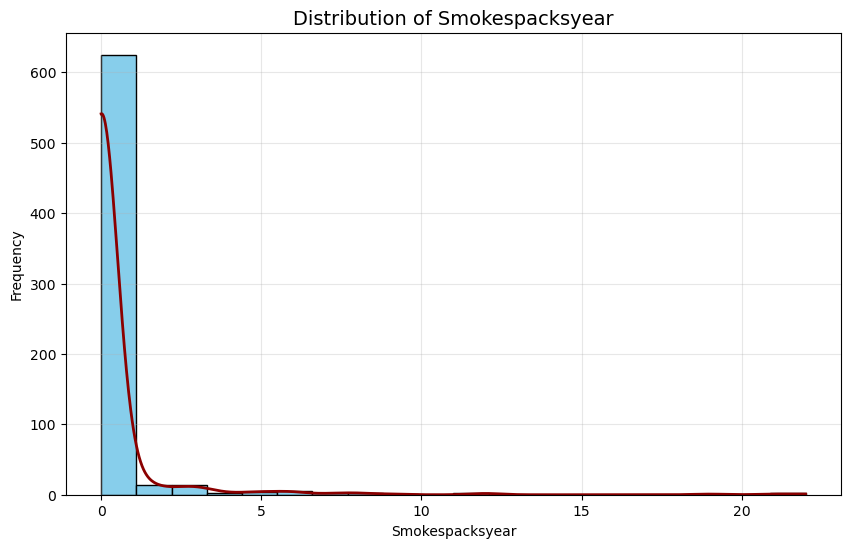

In [ ]:
def plot_missing_data(df, figsize=(12, 8)):
    """Create a bar plot showing missing values percentage for each column"""
    # Calculate missing values
    missing = df.isna().sum()
    total = len(df)
    percent_missing = (missing / total) * 100
    
    # Sort and filter
    percent_missing = percent_missing.sort_values(ascending=False)
    percent_missing = percent_missing[percent_missing > 0]
    
    # Create plot
    plt.figure(figsize=figsize)
    bars = plt.bar(percent_missing.index, percent_missing, color='skyblue')
    
    # Add percentage labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Customize plot
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylabel('Percentage Missing', fontsize=12)
    plt.title('Missing Values Distribution', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return percent_missing

def analyze_column(df, col_name):
    """Analyze a column with detailed statistics and distribution"""
    print(f"\n{'='*50}")
    print(f"Analysis of '{col_name}':")
    print('='*50)
    
    # Basic info
    n_missing = df[col_name].isna().sum()
    n_total = len(df)
    print(f"Missing values: {n_missing}/{n_total} ({n_missing/n_total*100:.1f}%)")
    
    # Skip analysis if all values missing
    if n_missing == n_total:
        print("All values missing - no further analysis possible")
        return
    
    # For numeric columns
    if pd.api.types.is_numeric_dtype(df[col_name]):
        # Summary statistics
        stats = df[col_name].describe(percentiles=[.25, .5, .75])
        print("\nSummary Statistics:")
        print(stats.to_string())
        
        # Distribution info
        print("\nDistribution Characteristics:")
        print(f"Mean: {stats['mean']:.2f}")
        print(f"Median: {stats['50%']:.2f}")
        print(f"Mode: {df[col_name].mode().values[0]}")
        
        # Create histogram
        plt.figure(figsize=(10, 6))
        n, bins, patches = plt.hist(df[col_name].dropna(), bins=20, color='skyblue', edgecolor='black')
        
        # Add distribution curve
        from scipy.stats import gaussian_kde
        data = df[col_name].dropna()
        if len(data) > 1:
            kde = gaussian_kde(data)
            x = np.linspace(data.min(), data.max(), 1000)
            plt.plot(x, kde(x)*len(data)*(bins[1]-bins[0]), color='darkred', linewidth=2)
        
        plt.title(f"Distribution of {col_name}", fontsize=14)
        plt.xlabel(col_name)
        plt.ylabel("Frequency")
        plt.grid(alpha=0.3)
        plt.show()
    
    # For categorical/binary columns
    else:
        # Value counts
        value_counts = df[col_name].value_counts(dropna=False)
        print("\nValue Counts:")
        print(value_counts.to_string())
        
        # Create bar plot
        plt.figure(figsize=(10, 6))
        value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f"Distribution of {col_name}", fontsize=14)
        plt.xlabel(col_name)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

# Combine features and target for analysis
train_combined = pd.concat([X_train, y_train], axis=1)

# Plot missing values percentage
print("\nMissing Values Analysis:")
missing_percent = plot_missing_data(train_combined)

# Analyze specific columns as in R script
target_columns = [
    'HormonalContraceptives',
    'HormonalContraceptivesyears',
    'STDs',
    'STDsnumber',
    'STDsNumberofdiagnosis',
    'Numofpregnancies',
    'Numberofsexualpartners',
    'Smokes',
    'Smokesyears',
    'Smokespacksyear'
]

# Filter to columns that actually exist in the dataset
existing_columns = [col for col in target_columns if col in train_combined.columns]

for col in existing_columns:
    analyze_column(train_combined, col)



*HormonalContraceptives* and *HormonalContraceptivesyears*: 
HormonalContraceptives: impute using mode since binary - missing would impute as 1 based on existing distribution
HormonalContraceptivesyears: mean 2.23 and median 0.42
HormonalContraceptives would impute as "yes" and years should match binary - impute using mean?

*STDs*, *STDsnumber*, and *STDsNumberofdiagnosis*: 
STDsNumberofdiagnosis: has no missing
STDsnumber: mean 0.17, mode 0 - use mode as someone cannot have "0.17" STDs
STDs: mode is 0
Keep STDsNumberofdiagnosis since there is no missing and remove STDsnumber; imputation of "no" for STDs would be consistent with current distribution of STDsNumberofdiagnosis

*Numofpregnancies* and *Numberofsexualpartners*:
Numofpregnancies: mean 2.26 and median 2.0
Numberofsexualpartners: mean 2.59 and median 2.0
Use median as mean for both of these is unrealistic (e.g., cannot have 2.26 pregnancies)

*Smokes*, *Smokesyears*, and *Smokespacksyear*:
Smokes: mode 0
Smokesyears: mean 1.07, mode 0
Smokespacksyear: mean 0.39, mode 0
Use mode for all for consistency

Need to keep in mind that there are several independent clinical/personal factors that affect each of these features.

Imputation will be completed using a random forest imputation to account for the clinical nature of the variables (e.g., a random forest imputation may detect patterns in the data that impute a "yes" instead of a "no" that would normally be imputed using standard imputation).

In [94]:
# Define categorical features
cat_features = [X_train.columns.get_loc(col) for col in [
    'Smokes', 'HormonalContraceptives', 'IUD', 'STDs', 
    'STDssyphilis', 'STDsHIV', 'DxCIN', 'Dx'
] if col in X_train]

# Imputation with random forest
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=1000),
    max_iter=10,
    random_state=250
)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

X_train_imputed.isna().sum()

/usr/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Age                            0
Numberofsexualpartners         0
Firstsexualintercourse         0
Numofpregnancies               0
Smokes                         0
Smokesyears                    0
Smokespacksyear                0
HormonalContraceptives         0
HormonalContraceptivesyears    0
IUD                            0
IUDyears                       0
STDs                           0
STDsnumber                     0
STDssyphilis                   0
STDsHIV                        0
STDsNumberofdiagnosis          0
DxCIN                          0
Dx                             0
dtype: int64

Need to verify that numeric values imputed appropriately based on type (e.g., whole numbers for Numberofsexualpartners, etc.)

In [98]:
print(X_train_imputed['Firstsexualintercourse'].value_counts())
print(X_train_imputed['Numberofsexualpartners'].value_counts())
print(X_train_imputed['Numofpregnancies'].value_counts())
print(X_train_imputed['Smokesyears'].value_counts())
print(X_train_imputed['Smokespacksyear'].value_counts())
print(X_train_imputed['HormonalContraceptivesyears'].value_counts())

Firstsexualintercourse
15.000    124
17.000    119
18.000    117
16.000     94
14.000     66
19.000     47
20.000     31
13.000     19
21.000     17
22.000      7
23.000      6
27.000      6
24.000      6
12.000      5
26.000      5
29.000      4
25.000      2
28.000      2
10.000      2
17.552      1
16.667      1
11.000      1
16.644      1
18.308      1
23.722      1
21.821      1
Name: count, dtype: int64
Numberofsexualpartners
2.000000     218
3.000000     176
1.000000     154
4.000000      66
5.000000      35
6.000000       8
7.000000       5
8.000000       4
2.057000       1
1.940933       1
2.802540       1
10.000000      1
4.126000       1
3.270000       1
2.237000       1
2.179000       1
1.792000       1
1.993783       1
2.572000       1
9.000000       1
2.265000       1
2.603000       1
2.225083       1
4.030000       1
28.000000      1
15.000000      1
1.671933       1
3.172000       1
Name: count, dtype: int64
Numofpregnancies
1.000000    217
2.000000    195
3.000000    1

Missing values for numeric columns were imputed as float and need to be integers. Will round the numeric columns.

In [99]:
# Round numeric columns
round_cols = ['Age', 'Numberofsexualpartners', 'Firstsexualintercourse', 'Numofpregnancies']
X_train_imputed[round_cols] = X_train_imputed[round_cols].round()
X_test_imputed[round_cols] = X_test_imputed[round_cols].round()

X_train_imputed

,Age,Numberofsexualpartners,Firstsexualintercourse,Numofpregnancies,Smokes,Smokesyears,Smokespacksyear,HormonalContraceptives,HormonalContraceptivesyears,IUD,IUDyears,STDs,STDsnumber,STDssyphilis,STDsHIV,STDsNumberofdiagnosis,DxCIN,Dx
0,21.0,1.0,20.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,20.0,3.0,18.0,2.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,23.0,3.0,16.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,19.0,4.0,14.0,1.0,0.0,0.0,0.0,1.0,0.647780,1.0,4.02658,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,42.0,2.0,29.0,0.0,0.0,0.0,0.0,1.0,8.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,21.0,5.0,17.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
682,21.0,1.0,14.0,2.0,0.0,0.0,0.0,1.0,4.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
683,16.0,3.0,14.0,1.0,0.0,0.0,0.0,1.0,0.756883,1.0,3.49094,0.0,0.0,0.0,0.0,0.0,0.0,0.0
684,20.0,5.0,14.0,3.0,1.0,4.0,3.0,1.0,2.688300,1.0,2.37377,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The target variable has severe class imbalance. Will use SMOTE-NC for balancing. This should improve model performance.

In [100]:
# SMOTE-NC application
smote_nc = SMOTENC(
    categorical_features=cat_features,
    sampling_strategy='auto',
    random_state=250
)
X_train_sm, y_train_sm = smote_nc.fit_resample(X_train_imputed, y_train)

Code to create a comprehensive model evaluation

In [120]:
def evaluate_model(model, X_test, y_test, model_name=""):
    """Comprehensive model evaluation with metrics and visualizations"""
    # Generate predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # 1. Classification report
    print(f"\n{'='*60}")
    print(f"{model_name.upper()} CLASSIFICATION REPORT")
    print('='*60)
    print(classification_report(y_test, y_pred, digits=3))
    
    # 2. Confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()
    
    # Only generate probability-based metrics if available
    if y_proba is not None:
        # 3. ROC Curve
        roc_auc = roc_auc_score(y_test, y_proba)
        print(f"ROC AUC: {roc_auc:.3f}")
        RocCurveDisplay.from_predictions(y_test, y_proba, name=model_name)
        plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
        plt.title(f'ROC Curve (AUC = {roc_auc:.3f})')
        plt.show()
        
        # 4. Precision-Recall Curve
        PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=model_name)
        plt.title('Precision-Recall Curve')
        plt.show()
    
    # 5. Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary', pos_label=1
    )
    accuracy = accuracy_score(y_test, y_pred)
    
    # Calculate specificity
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'roc_auc': roc_auc if y_proba is not None else None
    }
    
    print(f"\nDETAILED METRICS FOR {model_name.upper()}:")
    for metric, value in metrics.items():
        if value is not None:
            print(f"- {metric.capitalize():<12}: {value:.3f}")
    
    return metrics

Model definitions

In [121]:
# Define models with their parameters
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=250,
        class_weight='balanced',
        max_depth=5
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=500,  # Reduced for efficiency
        class_weight='balanced_subsample',
        random_state=250,
        max_depth=8,
        min_samples_split=10,
        n_jobs=-1
    )
}

Cross-validation function

In [122]:
def run_cross_validation(model, X, y, cv, cat_features):
    """Manual cross-validation to avoid pickling issues"""
    # Define scoring metrics
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, pos_label=1),
        'recall': make_scorer(recall_score, pos_label=1),
        'f1': make_scorer(f1_score, pos_label=1),
        'roc_auc': make_scorer(roc_auc_score, needs_proba=True),
        'specificity': make_scorer(recall_score, pos_label=0)
    }
    
    # Initialize results storage
    results = {f'train_{k}': [] for k in scoring.keys()}
    results.update({f'test_{k}': [] for k in scoring.keys()})
    
    # Manually iterate through folds
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        print(f"\nFold {fold_idx+1}/{cv.get_n_splits()}")
        
        # Split data
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[test_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[test_idx]
        
        # Create pipeline for this fold
        pipeline = imbPipeline([
            ('imputer', IterativeImputer(
                random_state=250,
                max_iter=20,
                tol=0.01,
                verbose=0
            )),
            ('smote', SMOTENC(
                categorical_features=cat_features,
                random_state=250,
                k_neighbors=5
            )),
            ('model', clone(model))  # Fresh model instance
        ])
        
        # Train pipeline
        pipeline.fit(X_train_fold, y_train_fold)
        
        # Get the trained model from the pipeline
        trained_model = pipeline.named_steps['model']
        
        # Evaluate on training fold
        for metric_name, scorer in scoring.items():
            try:
                # Training scores
                if 'train' in results:
                    train_score = scorer(trained_model, X_train_fold, y_train_fold)
                    results[f'train_{metric_name}'].append(train_score)
                
                # Validation scores
                val_score = scorer(trained_model, X_val_fold, y_val_fold)
                results[f'test_{metric_name}'].append(val_score)
                
                print(f"{metric_name}: Val={val_score:.3f}")
            except Exception as e:
                print(f"Error scoring {metric_name}: {str(e)}")
                results[f'test_{metric_name}'].append(np.nan)
    
    # Convert to arrays
    return {k: np.array(v) for k, v in results.items()}

Training and evaluation


STARTING MODEL: DECISION TREE

Training on SMOTE data...

Evaluating on test set...

DECISION TREE (TEST SET) CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0      0.994     0.994     0.994       168
           1      0.750     0.750     0.750         4

    accuracy                          0.988       172
   macro avg      0.872     0.872     0.872       172
weighted avg      0.988     0.988     0.988       172



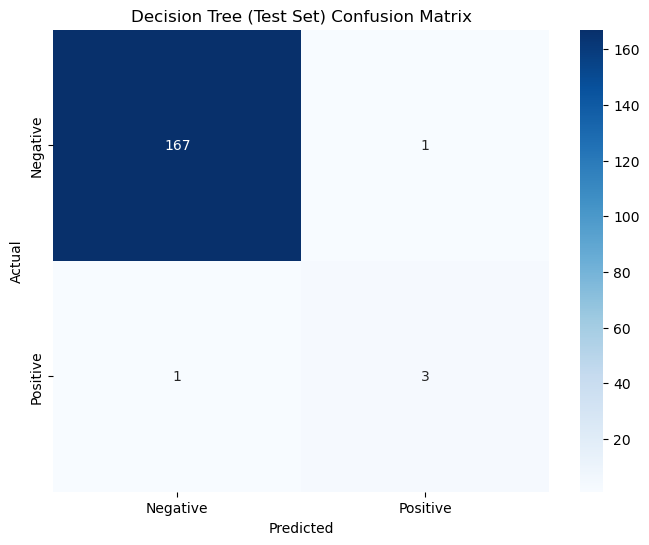

ROC AUC: 0.872


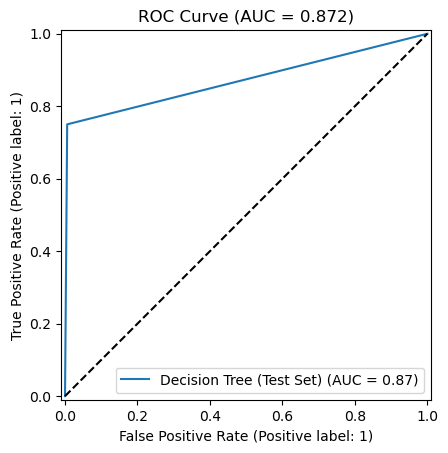

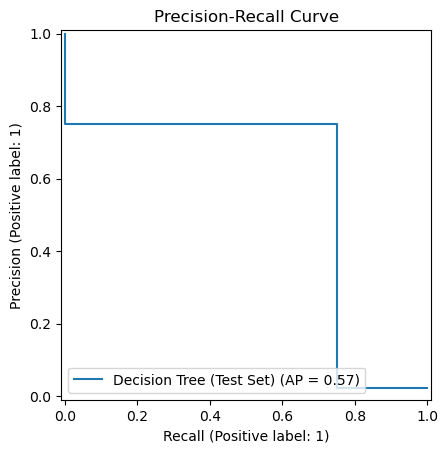


DETAILED METRICS FOR DECISION TREE (TEST SET):
- Accuracy    : 0.988
- Precision   : 0.750
- Recall      : 0.750
- F1          : 0.750
- Specificity : 0.994
- Roc_auc     : 0.872

Calculating feature importance...


/tmp/ipykernel_3101030/3654206238.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


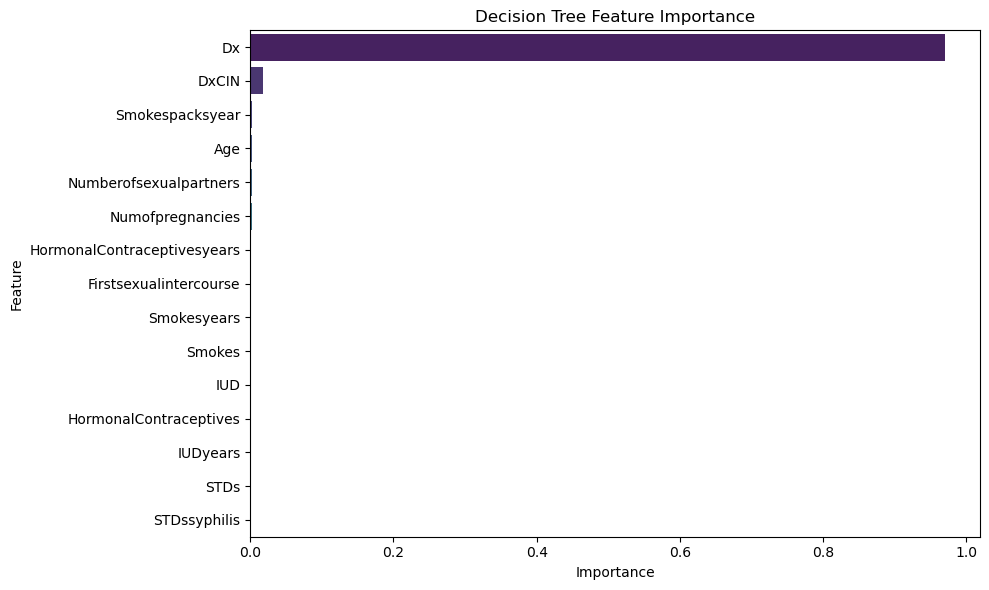


STARTING CROSS-VALIDATION FOR DECISION TREE:

Fold 1/3


/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


accuracy: Val=0.948
precision: Val=0.231
recall: Val=0.600
f1: Val=0.333
Error scoring roc_auc: got an unexpected keyword argument 'needs_proba'
specificity: Val=0.955

Fold 2/3


/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but

accuracy: Val=0.983
precision: Val=0.571
recall: Val=0.800
f1: Val=0.667
Error scoring roc_auc: got an unexpected keyword argument 'needs_proba'
specificity: Val=0.987

Fold 3/3
accuracy: Val=0.991
precision: Val=1.000
recall: Val=0.500
f1: Val=0.667
Error scoring roc_auc: got an unexpected keyword argument 'needs_proba'
specificity: Val=1.000

CROSS-VALIDATION SUMMARY FOR Decision Tree:
  Accuracy Train: nan ± nan
  Accuracy Val:   0.974 ± 0.019
  Precision Train: nan ± nan
  Precision Val:   0.601 ± 0.315
  Recall Train: nan ± nan
  Recall Val:   0.633 ± 0.125
  F1 Train: nan ± nan
  F1 Val:   0.556 ± 0.157
  Roc_auc Train: nan ± nan
  Roc_auc Val:   nan ± nan
  Specificity Train: nan ± nan
  Specificity Val:   0.981 ± 0.019

STARTING MODEL: RANDOM FOREST

Training on SMOTE data...


/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but


Evaluating on test set...

RANDOM FOREST (TEST SET) CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0      0.988     1.000     0.994       168
           1      1.000     0.500     0.667         4

    accuracy                          0.988       172
   macro avg      0.994     0.750     0.830       172
weighted avg      0.989     0.988     0.986       172



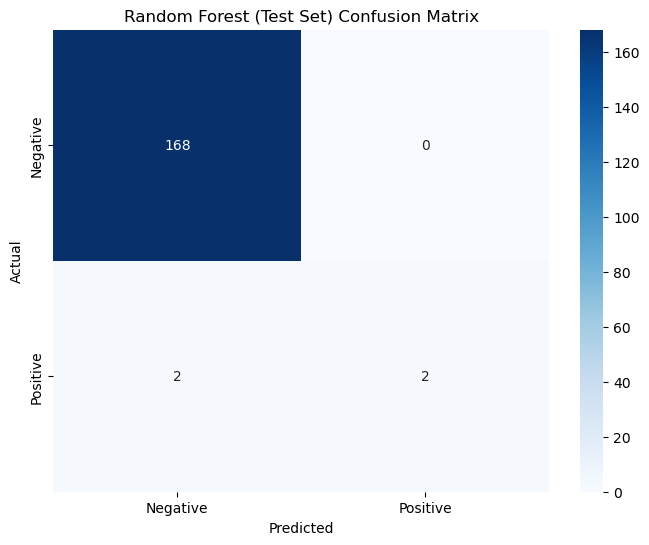

ROC AUC: 0.893


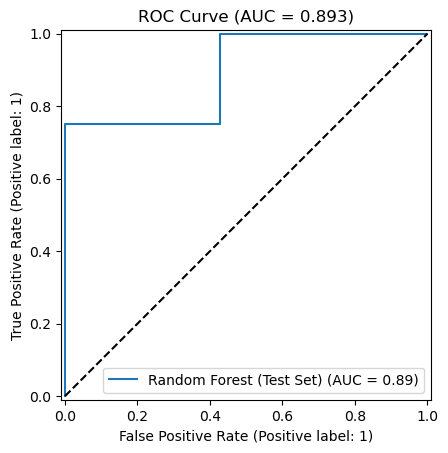

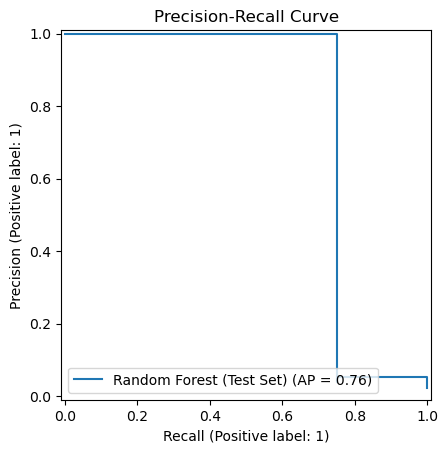


DETAILED METRICS FOR RANDOM FOREST (TEST SET):
- Accuracy    : 0.988
- Precision   : 1.000
- Recall      : 0.500
- F1          : 0.667
- Specificity : 1.000
- Roc_auc     : 0.893

Calculating feature importance...


/tmp/ipykernel_3101030/3654206238.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


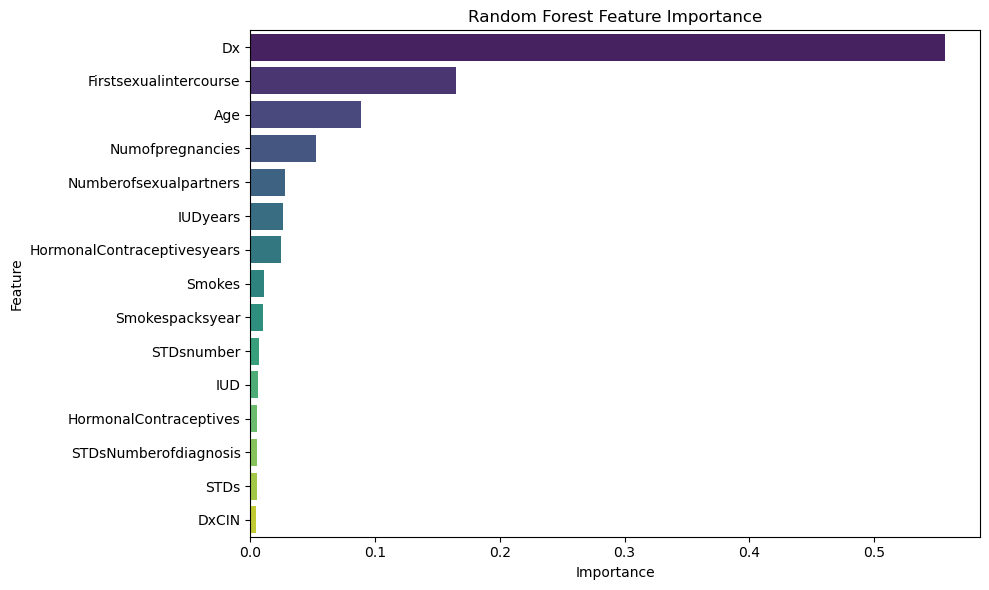


STARTING CROSS-VALIDATION FOR RANDOM FOREST:

Fold 1/3


/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


accuracy: Val=0.991
precision: Val=0.800
recall: Val=0.800
f1: Val=0.800


/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Error scoring roc_auc: got an unexpected keyword argument 'needs_proba'
specificity: Val=0.996

Fold 2/3


...

/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Error scoring roc_auc: got an unexpected keyword argument 'needs_proba'
specificity: Val=0.991

Fold 3/3


/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


accuracy: Val=0.987
precision: Val=1.000
recall: Val=0.250
f1: Val=0.400
Error scoring roc_auc: got an unexpected keyword argument 'needs_proba'
specificity: Val=1.000

CROSS-VALIDATION SUMMARY FOR Random Forest:
  Accuracy Train: nan ± nan
  Accuracy Val:   0.988 ± 0.002
  Precision Train: nan ± nan
  Precision Val:   0.822 ± 0.137
  Recall Train: nan ± nan
  Recall Val:   0.617 ± 0.259
  F1 Train: nan ± nan
  F1 Val:   0.642 ± 0.174
  Roc_auc Train: nan ± nan
  Roc_auc Val:   nan ± nan
  Specificity Train: nan ± nan
  Specificity Val:   0.996 ± 0.004


/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/tmp/ipykernel_3101030/3654206238.py:57: RuntimeWarning: Mean of empty slice.
  print(f"  {metric.capitalize()} Train: {train_scores.mean():.3f} ± {train_scores.std():.3f}")
/usr/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_d

In [123]:
# Cross-validation strategy (3-fold for efficiency)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=250)

# Dictionary to store all results
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"STARTING MODEL: {name.upper()}")
    print('='*60)
    
    # 1. Train model on SMOTE training data
    print("\nTraining on SMOTE data...")
    model.fit(X_train_sm, y_train_sm)
    
    # 2. Evaluate on test set
    print("\nEvaluating on test set...")
    test_metrics = evaluate_model(model, X_test_imputed, y_test, f"{name} (Test Set)")
    results[name] = {'test_metrics': test_metrics}
    
    # 3. Feature Importance
    if hasattr(model, 'feature_importances_'):
        print("\nCalculating feature importance...")
        importance = pd.DataFrame({
            'Feature': X_train_sm.columns,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', 
                    data=importance.head(15), palette='viridis')
        plt.title(f'{name} Feature Importance')
        plt.tight_layout()
        plt.show()
    
    # 4. Cross-Validation
    print(f"\nSTARTING CROSS-VALIDATION FOR {name.upper()}:")
    cv_results = run_cross_validation(
        model,
        X_train,  # Original training data
        y_train,
        cv,
        cat_features
    )
    
    # Store CV results
    results[name]['cv_results'] = cv_results
    
    # Print CV summary
    print(f"\nCROSS-VALIDATION SUMMARY FOR {name}:")
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'specificity']:
        train_key = f'train_{metric}'
        test_key = f'test_{metric}'
        
        if train_key in cv_results:
            train_scores = cv_results[train_key]
            print(f"  {metric.capitalize()} Train: {train_scores.mean():.3f} ± {train_scores.std():.3f}")
        
        if test_key in cv_results:
            test_scores = cv_results[test_key]
            print(f"  {metric.capitalize()} Val:   {test_scores.mean():.3f} ± {test_scores.std():.3f}")

Final model comparison

In [124]:
print("\n\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

# Create comparison table
comparison_data = []
for name, res in results.items():
    row = {
        'Model': name,
        'Accuracy': res['test_metrics']['accuracy'],
        'Precision': res['test_metrics']['precision'],
        'Recall': res['test_metrics']['recall'],
        'F1': res['test_metrics']['f1'],
        'Specificity': res['test_metrics']['specificity'],
        'ROC AUC': res['test_metrics']['roc_auc']
    }
    comparison_data.append(row)

# Create and display DataFrame
comparison_df = pd.DataFrame(comparison_data).set_index('Model')
print("\nTEST SET PERFORMANCE:")
print(comparison_df.round(3))



MODEL PERFORMANCE COMPARISON

TEST SET PERFORMANCE:
               Accuracy  Precision  Recall     F1  Specificity  ROC AUC
Model                                                                  
Decision Tree     0.988       0.75    0.75  0.750        0.994    0.872
Random Forest     0.988       1.00    0.50  0.667        1.000    0.893


Best model selection

In [125]:
# Select best model based on F1 score
best_model_name = comparison_df['F1'].idxmax()
best_model = models[best_model_name]
best_score = comparison_df.loc[best_model_name, 'F1']

print(f"\nBEST MODEL: {best_model_name} (F1 = {best_score:.3f})")

# Save best model
joblib.dump(best_model, 'best_model.pkl')
print("Saved best model as 'best_model.pkl'")


BEST MODEL: Decision Tree (F1 = 0.750)
Saved best model as 'best_model.pkl'


Detailed report and feature importance for best model


DETAILED BEST MODEL REPORT: Decision Tree

TEST SET PERFORMANCE:
- Accuracy    : 0.988
- Precision   : 0.750
- Recall      : 0.750
- F1          : 0.750
- Specificity : 0.994
- Roc_auc     : 0.872

TOP 10 FEATURES:
                    Feature  Importance
                         Dx    0.970494
                      DxCIN    0.017646
            Smokespacksyear    0.002880
                        Age    0.002834
     Numberofsexualpartners    0.002355
           Numofpregnancies    0.002121
HormonalContraceptivesyears    0.000815
     Firstsexualintercourse    0.000763
                Smokesyears    0.000091
                     Smokes    0.000000


/tmp/ipykernel_3101030/3863373206.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


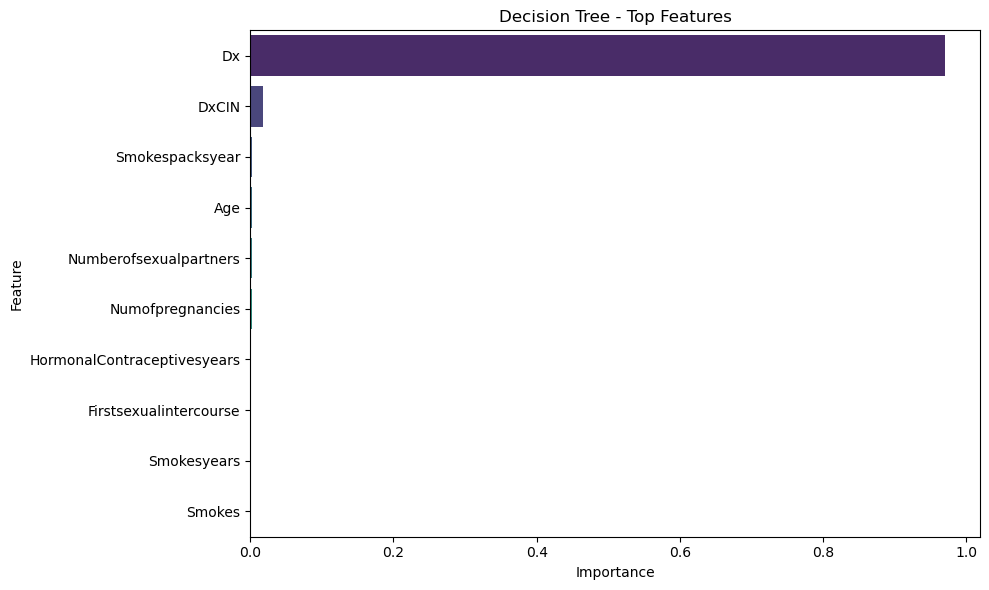

In [126]:
print("\n" + "="*60)
print(f"DETAILED BEST MODEL REPORT: {best_model_name}")
print("="*60)

# Show best model test metrics
print("\nTEST SET PERFORMANCE:")
for metric, value in results[best_model_name]['test_metrics'].items():
    if value is not None:
        print(f"- {metric.capitalize():<12}: {value:.3f}")

# Show feature importance if available
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X_train_sm.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTOP 10 FEATURES:")
    print(importance.head(10).to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', 
                data=importance.head(10), palette='viridis')
    plt.title(f'{best_model_name} - Top Features')
    plt.tight_layout()
    plt.show()

The decision tree model trained on the balanced dataset has better performance than the random forest model. The random forest model has 2 false negatives compared to the decision tree's 1 false negative. 

False negatives are highly detrimental in this model as a false negative indicates that a patient was incorrectly determined to not have cancer. This can have significant consequences, such as delayed treatment, worsening condition, and potentially a preventable death.

The decision tree model had 1 false positive compared to no false positives for the random forest model. A false positive is less detrimental than a false negative. However, there are still significant impacts, most notably the anxiety caused to the patient due to worrying about a possible cervical cancer diagnosis. Additionally, testing-related costs (biopsy/citology confirmation) and the increased burden on already strained health systems are other notable impacts.

Regarding feature importance, both models relied heavily on the 'Dx' feature, which is a previous cervical diagnosis (it is unclear from study documentation if this refers to any cervical diagnosis or a previous cervical cancer diagnosis). This is information that *should* be readily available, either through patient self-provided history during exam or through existing health records. However, there are instances where this information may not be available, such as in areas with poor health systems. Removing this feature could significantly impact model performance. Notably, the random forest model had significantly higher variable importance for the remaining variables compared to the decision tree model, likely owing to the underlying nature of the models (e.g., decision trees generally split and "don't look back" while random forests "grow and vote").